##**Dog vs Cat Classification using Transfer Learning**

**Transfer Learning** is a deep learning technique where we use a pre-trained model. This pre-trained model is trained for one task and can be retrained for the similar task with smaller dataset.  
Transfer learning gives a higher accuracy compared to a trained model from scratch.  
Examples :    
VGG - 16  
ResNet 50  
Inceptionv3  
MobileNet20  

In [1]:
!pip install kaggle

In [24]:
#configuring the path of kaggle json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [25]:
#importing the cat vs dog dataset from kaggle
!kaggle competitions download -c dogs-vs-cats

In [26]:
!ls

dogs-vs-cats.zip  drive  kaggle.json  sample_data


In [27]:
# extracting the dataset
from zipfile import ZipFile
dataset = "/content/dogs-vs-cats.zip"
with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The dataset if extracted")

The dataset if extracted


In [28]:
# extracting the dataset
from zipfile import ZipFile
dataset = "/content/train.zip"
with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The dataset if extracted")

The dataset if extracted


In [29]:
import os
#count the number of files in trained folder
path, dir, files = next(os.walk("/content/train"))
file_count = len(files)
print("Number of images : ",file_count)

Number of images :  25000


Printing the names of images

In [30]:
file_names = os.listdir("/content/train")
print(file_names)

['dog.7018.jpg', 'dog.12435.jpg', 'cat.6116.jpg', 'cat.5353.jpg', 'cat.6475.jpg', 'dog.4932.jpg', 'dog.10672.jpg', 'dog.7153.jpg', 'cat.7782.jpg', 'dog.11305.jpg', 'dog.4086.jpg', 'dog.523.jpg', 'cat.10967.jpg', 'dog.10800.jpg', 'dog.2565.jpg', 'dog.1531.jpg', 'cat.12007.jpg', 'cat.264.jpg', 'dog.3263.jpg', 'dog.2544.jpg', 'cat.7098.jpg', 'dog.3118.jpg', 'cat.2081.jpg', 'dog.2691.jpg', 'cat.2757.jpg', 'dog.1960.jpg', 'dog.4906.jpg', 'cat.2021.jpg', 'cat.2046.jpg', 'cat.5538.jpg', 'dog.5495.jpg', 'cat.7451.jpg', 'dog.8954.jpg', 'cat.7941.jpg', 'dog.2634.jpg', 'dog.4946.jpg', 'dog.10668.jpg', 'dog.3817.jpg', 'cat.7647.jpg', 'dog.1007.jpg', 'cat.3263.jpg', 'cat.2878.jpg', 'dog.1621.jpg', 'cat.2612.jpg', 'dog.4355.jpg', 'cat.845.jpg', 'cat.12217.jpg', 'cat.9638.jpg', 'cat.12014.jpg', 'cat.7502.jpg', 'dog.7910.jpg', 'dog.12111.jpg', 'cat.1102.jpg', 'cat.11927.jpg', 'cat.9765.jpg', 'cat.8821.jpg', 'cat.8153.jpg', 'dog.10928.jpg', 'cat.8667.jpg', 'dog.5188.jpg', 'cat.8347.jpg', 'dog.12309.jpg

Importing the dependencies

In [31]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

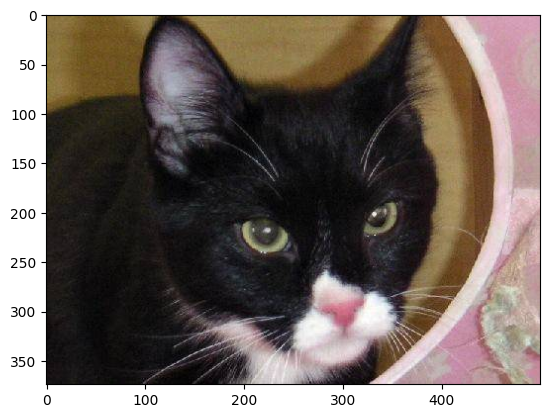

In [36]:
#displaying the images of cat and dog
img = mpimg.imread("/content/train/cat.10001.jpg")
imgplot = plt.imshow(img)
plt.show()

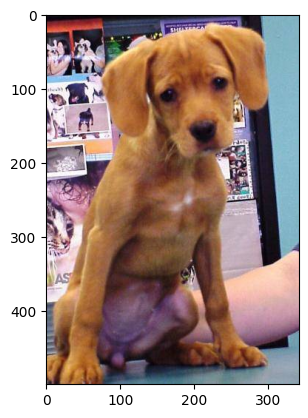

In [37]:
img = mpimg.imread("/content/train/dog.1234.jpg")
imgplot = plt.imshow(img)
plt.show()

In [38]:
dog_count = 0
cat_count = 0
for img_file in file_names:
  name = img_file[0:3]
  if name == "dog" :
    dog_count += 1
  else :
    cat_count += 1
print("Number of dogs : ",dog_count)
print("Number of cats : ",cat_count)

Number of dogs :  12500
Number of cats :  12500


Resizing all the images

In [42]:
#creating a directory for the resized images
os.mkdir("/content/image_resized")

In [43]:
original_folder = "/content/train/"
resized_folder = "/content/image_resized/"
for i in range(2000) :
  filename = os.listdir(original_folder)[i]
  img_path = original_folder + filename

  img = Image.open(img_path)
  img = img.resize((224,224))
  img = img.convert('RGB')

  newImgpath = resized_folder + filename
  img.save(newImgpath)

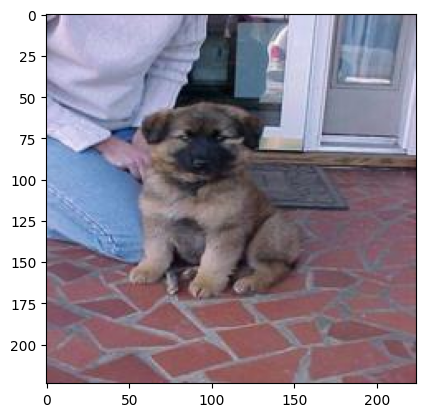

In [49]:
img = mpimg.imread("/content/image_resized/dog.10150.jpg")
imgplot = plt.imshow(img)
plt.show()

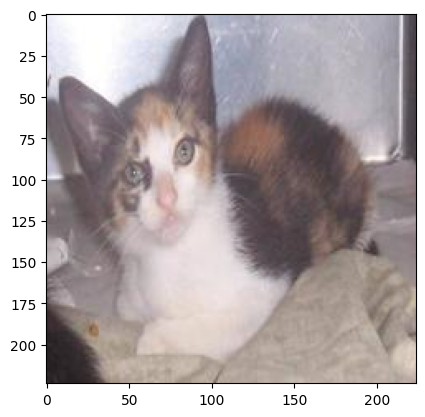

In [47]:
img = mpimg.imread("/content/image_resized/cat.10015.jpg")
imgplot = plt.imshow(img)
plt.show()

Creating labels of resized images  
Cat -> 0  
Dog -> 1

In [55]:
#creating a for loop to assign labels
filenames = os.listdir("/content/image_resized")

labels = []

for i in range(2000) :
  file_name = file_names[i]
  label = file_name[0:3]

  if(label == 'dog') :
    labels.append(1)
  else :
    labels.append(0)

In [56]:
print(filenames[0:5])
print(len(filenames))

['dog.7018.jpg', 'dog.12435.jpg', 'cat.6116.jpg', 'cat.5353.jpg', 'cat.6475.jpg']
2000


In [57]:
print(labels[0:5])
print(len(labels))

[1, 1, 0, 0, 0]
2000


In [69]:
values, counts = np.unique(labels, return_counts = True)
print(values)
print(counts)

[0 1]
[ 982 1018]


Converting the resized images to numpy arrays


In [70]:
import cv2
import glob

In [73]:
image_directory = "/content/image_resized/"
image_extension = ["jpg", "png"]

files = []
[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension] # do this when the images are in jpg and png format mixed
dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [74]:
print(dog_cat_images)

[[[[196 202 207]
   [197 203 208]
   [198 204 209]
   ...
   [150 229 218]
   [127 206 193]
   [121 200 187]]

  [[196 202 207]
   [197 203 208]
   [199 205 210]
   ...
   [135 214 203]
   [127 206 193]
   [129 208 195]]

  [[197 203 208]
   [198 204 209]
   [199 205 210]
   ...
   [137 216 205]
   [139 217 206]
   [140 216 205]]

  ...

  [[ 76 150 124]
   [ 76 150 124]
   [ 59 133 107]
   ...
   [ 88 164 132]
   [ 84 162 125]
   [ 94 173 134]]

  [[ 86 160 132]
   [ 74 148 120]
   [ 59 134 106]
   ...
   [101 177 143]
   [ 82 161 120]
   [ 71 151 108]]

  [[ 97 171 141]
   [ 77 151 121]
   [ 64 139 111]
   ...
   [100 177 140]
   [ 92 171 130]
   [ 88 169 124]]]


 [[[251 255 251]
   [242 250 243]
   [210 224 220]
   ...
   [ 70  86  69]
   [ 64  77  61]
   [ 49  62  46]]

  [[243 249 244]
   [250 255 252]
   [220 231 229]
   ...
   [ 42  58  41]
   [ 33  46  32]
   [ 14  27  11]]

  [[231 233 233]
   [251 255 255]
   [229 236 239]
   ...
   [ 34  47  33]
   [ 31  41  29]
   [ 16  26

In [75]:
type(dog_cat_images)

numpy.ndarray

In [76]:
dog_cat_images.shape

(2000, 224, 224, 3)

In [77]:
X = dog_cat_images
y = np.asarray(labels)

Train Test Split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2)

In [79]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600 -> training images  
400 -> test images

In [80]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [81]:
print(X_train_scaled)

[[[[0.05098039 0.04705882 0.05490196]
   [0.05098039 0.04705882 0.05490196]
   [0.05098039 0.04705882 0.0627451 ]
   ...
   [0.02352941 0.02352941 0.02352941]
   [0.02352941 0.02352941 0.02352941]
   [0.02352941 0.02352941 0.02352941]]

  [[0.05490196 0.05098039 0.05882353]
   [0.05098039 0.04705882 0.05490196]
   [0.05098039 0.04705882 0.0627451 ]
   ...
   [0.02352941 0.02352941 0.02352941]
   [0.02352941 0.02352941 0.02352941]
   [0.02352941 0.02352941 0.02352941]]

  [[0.05490196 0.05098039 0.06666667]
   [0.05490196 0.05098039 0.06666667]
   [0.05098039 0.04313725 0.06666667]
   ...
   [0.02352941 0.02352941 0.02352941]
   [0.02352941 0.02352941 0.02352941]
   [0.02352941 0.02352941 0.02352941]]

  ...

  [[0.03137255 0.03137255 0.03137255]
   [0.03137255 0.03137255 0.03137255]
   [0.02745098 0.02745098 0.02745098]
   ...
   [0.03137255 0.03529412 0.02745098]
   [0.03137255 0.03529412 0.02745098]
   [0.03529412 0.03921569 0.03137255]]

  [[0.01960784 0.01960784 0.01960784]
   [0.0

Building the neural network

In [82]:
import tensorflow as tf
import tensorflow_hub as hub

In [96]:
!pip install tf_keras
import tf_keras

In [93]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'
pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [98]:
number_of_classes = 2

model = tf_keras.Sequential([
    pretrained_model, #input layers
    tf_keras.layers.Dense(number_of_classes)
])
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [101]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ['acc']
)

In [102]:
model.fit(X_train_scaled, y_train, epochs = 5)

Epoch 1/5
50/50 [==============================] - 64s 1s/step - loss: 0.1551 - acc: 0.9431
Epoch 2/5
50/50 [==============================] - 62s 1s/step - loss: 0.0571 - acc: 0.9819
Epoch 3/5
50/50 [==============================] - 62s 1s/step - loss: 0.0406 - acc: 0.9850
Epoch 4/5
50/50 [==============================] - 60s 1s/step - loss: 0.0307 - acc: 0.9919
Epoch 5/5
50/50 [==============================] - 68s 1s/step - loss: 0.0258 - acc: 0.9937


In [103]:
score, acc = model.evaluate(X_test_scaled, y_test)
print('Test loss : ', score)
print('Test accuracy : ', acc)

13/13 [==============================] - 17s 1s/step - loss: 0.0378 - acc: 0.9875
Test loss :  0.037833988666534424
Test accuracy :  0.987500011920929


Build the predictive system

Path of the image to be predicted/content/dog.jpg


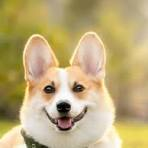

1/1 [==============================] - 0s 95ms/step
The image is of a dog


In [106]:
input_image_path = input("Path of the image to be predicted")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3]) #to tell model that we are making prediction for a single image

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction) # prediction probability of label

if input_pred_label == 0 :
  print("The image is of a cat")
else :
  print("The image is of a dog")